In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# ── CREATE BUDGET vs ACTUAL DATA ──
np.random.seed(42)

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

departments = ['Sales','Marketing','Operations','HR','Finance']

rows = []
for dept in departments:
    base = np.random.randint(80000, 200000)
    for i, month in enumerate(months):
        budget = base + (i * np.random.randint(1000, 5000))
        actual = budget * np.random.uniform(0.85, 1.18)
        rows.append({
            'Department': dept,
            'Month': month,
            'Month_Num': i+1,
            'Budget': round(budget, 2),
            'Actual': round(actual, 2),
        })

df = pd.DataFrame(rows)
df['Variance'] = df['Actual'] - df['Budget']
df['Variance_Pct'] = ((df['Actual'] - df['Budget']) / df['Budget'] * 100).round(1)
df['Status'] = df['Variance'].apply(lambda x: 'Over Budget' if x > 0 else 'Under Budget')

print("✅ Dataset ready!")
print(f"Departments: {df['Department'].nunique()}")
print(f"Months: {df['Month'].nunique()}")
print(f"Total Budget:  £{df['Budget'].sum():,.2f}")
print(f"Total Actual:  £{df['Actual'].sum():,.2f}")
print(f"Total Variance: £{df['Variance'].sum():,.2f}")
df.head(10)

✅ Dataset ready!
Departments: 5
Months: 12
Total Budget:  £7,693,402.00
Total Actual:  £7,660,633.58
Total Variance: £-32,768.42


,Department,Month,Month_Num,Budget,Actual,Variance,Variance_Pct,Status
0,Sales,Jan,1,95795,87224.55,-8570.45,-8.9,Under Budget
1,Sales,Feb,2,97890,102545.38,4655.38,4.8,Over Budget
2,Sales,Mar,3,101071,100780.40,-290.60,-0.3,Under Budget
3,Sales,Apr,4,102509,89097.50,-13411.50,-13.1,Under Budget
4,Sales,May,5,108335,104015.02,-4319.98,-4.0,Under Budget
5,Sales,Jun,6,115390,125043.98,9653.98,8.4,Over Budget
6,Sales,Jul,7,111905,97202.45,-14702.55,-13.1,Under Budget
7,Sales,Aug,8,119532,134438.37,14906.37,12.5,Over Budget
8,Sales,Sep,9,126619,107658.69,-18960.31,-15.0,Under Budget
9,Sales,Oct,10,113390,103244.26,-10145.74,-8.9,Under Budget


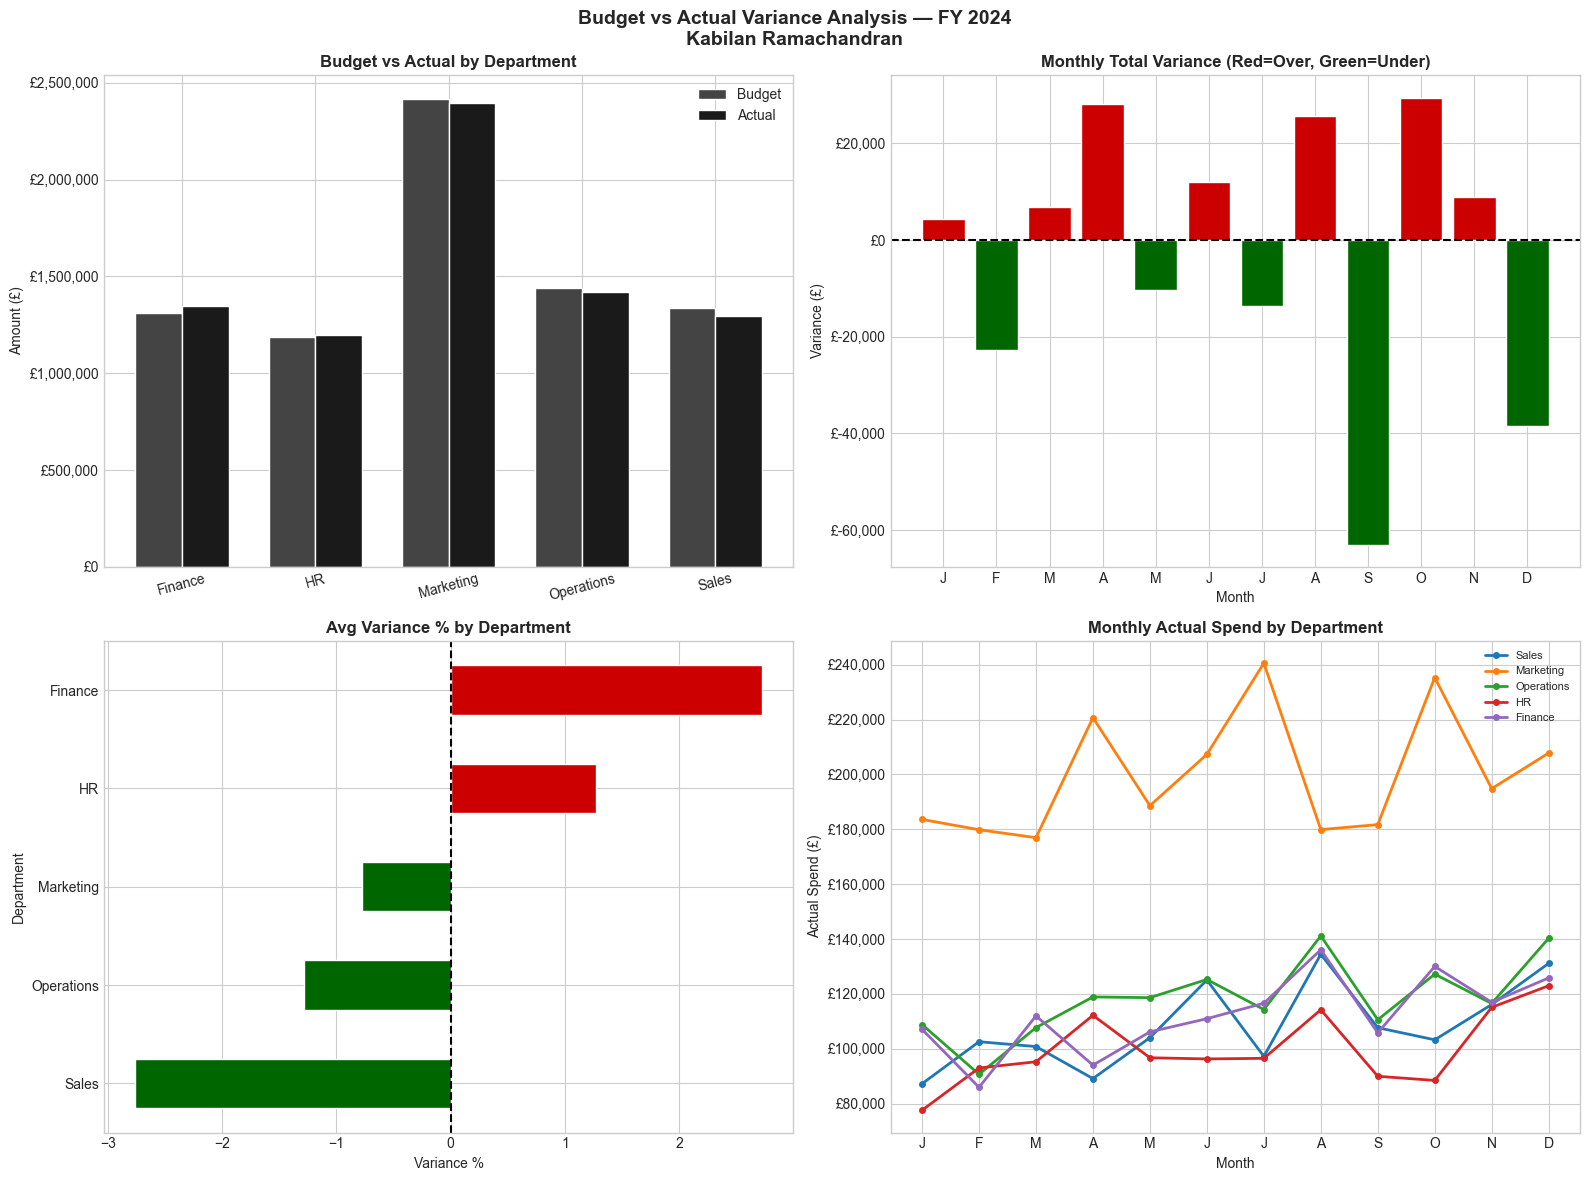

✅ Charts saved!


In [2]:
# ── VISUALISATIONS ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Budget vs Actual Variance Analysis — FY 2024\nKabilan Ramachandran',
             fontsize=14, fontweight='bold')

# Chart 1: Budget vs Actual by Department
ax1 = axes[0,0]
dept_summary = df.groupby('Department')[['Budget','Actual']].sum()
x = np.arange(len(dept_summary))
width = 0.35
ax1.bar(x - width/2, dept_summary['Budget'], width, label='Budget', color='#444444', edgecolor='white')
ax1.bar(x + width/2, dept_summary['Actual'], width, label='Actual', color='#1A1A1A', edgecolor='white')
ax1.set_title('Budget vs Actual by Department', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(dept_summary.index, rotation=15)
ax1.set_ylabel('Amount (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
ax1.legend()

# Chart 2: Monthly Variance Trend
ax2 = axes[0,1]
monthly = df.groupby('Month_Num')['Variance'].sum().reset_index()
colors = ['#CC0000' if v > 0 else '#006600' for v in monthly['Variance']]
ax2.bar(monthly['Month_Num'], monthly['Variance'], color=colors, edgecolor='white')
ax2.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax2.set_title('Monthly Total Variance (Red=Over, Green=Under)', fontweight='bold')
ax2.set_xlabel('Month'); ax2.set_ylabel('Variance (£)')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# Chart 3: Variance % by Department
ax3 = axes[1,0]
dept_var = df.groupby('Department')['Variance_Pct'].mean().sort_values()
colors3 = ['#CC0000' if v > 0 else '#006600' for v in dept_var.values]
dept_var.plot(kind='barh', ax=ax3, color=colors3, edgecolor='white')
ax3.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
ax3.set_title('Avg Variance % by Department', fontweight='bold')
ax3.set_xlabel('Variance %')

# Chart 4: Budget vs Actual Trend — All Departments
ax4 = axes[1,1]
for dept in departments:
    dept_df = df[df['Department']==dept]
    ax4.plot(dept_df['Month_Num'], dept_df['Actual'],
             marker='o', linewidth=2, markersize=4, label=dept)
ax4.set_title('Monthly Actual Spend by Department', fontweight='bold')
ax4.set_xlabel('Month'); ax4.set_ylabel('Actual Spend (£)')
ax4.set_xticks(range(1,13))
ax4.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('budget_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

In [3]:
# ── INSIGHTS ──
print("=" * 55)
print("   BUDGET vs ACTUAL — EXECUTIVE SUMMARY")
print("=" * 55)

print(f"\n📊 OVERALL PERFORMANCE")
total_budget = df['Budget'].sum()
total_actual = df['Actual'].sum()
total_var = df['Variance'].sum()
print(f"   Total Budget:    £{total_budget:,.2f}")
print(f"   Total Actual:    £{total_actual:,.2f}")
print(f"   Total Variance:  £{total_var:,.2f} ({total_var/total_budget*100:.1f}%)")
status = "UNDER BUDGET ✅" if total_var < 0 else "OVER BUDGET ⚠️"
print(f"   Status: {status}")

print(f"\n📁 DEPARTMENT BREAKDOWN")
dept_sum = df.groupby('Department').agg(
    Budget=('Budget','sum'),
    Actual=('Actual','sum'),
    Variance=('Variance','sum')
).round(2)
dept_sum['Var%'] = (dept_sum['Variance']/dept_sum['Budget']*100).round(1)
for dept, row in dept_sum.iterrows():
    icon = "🔴" if row['Variance'] > 0 else "🟢"
    print(f"   {icon} {dept}: £{row['Variance']:+,.2f} ({row['Var%']:+.1f}%)")

print(f"\n📅 WORST MONTHS (Over Budget)")
over = df[df['Status']=='Over Budget'].nlargest(3,'Variance')[['Month','Department','Variance','Variance_Pct']]
for _, row in over.iterrows():
    print(f"   {row['Month']} — {row['Department']}: £{row['Variance']:+,.2f} ({row['Variance_Pct']:+.1f}%)")

print(f"\n📅 BEST MONTHS (Under Budget)")
under = df[df['Status']=='Under Budget'].nsmallest(3,'Variance')[['Month','Department','Variance','Variance_Pct']]
for _, row in under.iterrows():
    print(f"   {row['Month']} — {row['Department']}: £{row['Variance']:+,.2f} ({row['Variance_Pct']:+.1f}%)")

print("\n" + "="*55)
print("✅ Report Complete — Kabilan Ramachandran")
print("="*55)

   BUDGET vs ACTUAL — EXECUTIVE SUMMARY

📊 OVERALL PERFORMANCE
   Total Budget:    £7,693,402.00
   Total Actual:    £7,660,633.58
   Total Variance:  £-32,768.42 (-0.4%)
   Status: UNDER BUDGET ✅

📁 DEPARTMENT BREAKDOWN
   🔴 Finance: £+34,184.13 (+2.6%)
   🔴 HR: £+11,563.93 (+1.0%)
   🟢 Marketing: £-20,909.42 (-0.9%)
   🟢 Operations: £-21,159.45 (-1.5%)
   🟢 Sales: £-36,447.61 (-2.7%)

📅 WORST MONTHS (Over Budget)
   Oct — Marketing: £+33,962.78 (+16.9%)
   Jul — Marketing: £+28,385.78 (+13.4%)
   Apr — Marketing: £+21,710.87 (+10.9%)

📅 BEST MONTHS (Under Budget)
   Sep — Marketing: £-30,971.30 (-14.6%)
   Dec — Marketing: £-27,741.12 (-11.8%)
   Sep — Sales: £-18,960.31 (-15.0%)

✅ Report Complete — Kabilan Ramachandran
